In [1]:

import numpy as np
import torch
from cebmf_torch import * 
 
from cebmf_torch.utils.mixture import * 
from cebmf_torch.utils.posterior import * 
from cebmf_torch.utils.distribution_operation import * 
import matplotlib.pyplot as plt
from cebmf_torch.ebnm.ash import ash


In [2]:
my_etruncnorm(0,2,3,1).cpu().numpy() # should close to  1.48995049

array(1.4899508, dtype=float32)

In [3]:
my_etruncnorm(0,2,3,1).detach

<function Tensor.detach>

In [4]:
my_e2truncnorm(0,2,3,1) # should be close to, 2.39340536

tensor(2.3934)

In [5]:
betahat=  np.array([1,2,3,4,5], dtype=float)
sebetahat=np.array([1,0.4,5,1,1], dtype=float)
device = torch.device('cpu')
scale = autoselect_scales_mix_exp ( torch.tensor(betahat),  torch.tensor(sebetahat)).cpu().numpy()

In [6]:
betahat = torch.tensor([1.,2.,3.,4.,5.])
sebetahat = torch.tensor([1.,0.4,5.,1.,1.])
mult = torch.sqrt(torch.tensor(2.0)).item()
res = ash(betahat, sebetahat, prior="exp", mult=mult, penalty=6 )
expected_log_lik = -15.244064765169643
expected_scale = np.array([ 0.        , 0.02929687, 0.04143204, 0.05859375, 0.08286408,
                                0.1171875 , 0.16572815, 0.234375  , 0.3314563 , 0.46875   ,
                                0.66291261, 0.9375    , 1.32582521, 1.875     , 2.65165043,
                                3.75      , 5.30330086, 7.5       ])

In [7]:
res.post_mean2

tensor([ 0.5346,  3.9507,  4.4566, 14.4657, 22.8752])

In [8]:
res.log_lik

tensor(-14.0631)

In [9]:
res.scale

tensor([0.0000, 0.0293, 0.0414, 0.0586, 0.0829, 0.1172, 0.1657, 0.2344, 0.3315,
        0.4687, 0.6629, 0.9375, 1.3258, 1.8750, 2.6517, 3.7500, 5.3033, 7.5000])

In [10]:
non_informativ = np.full( scale.shape[0], 1/ scale.shape[0])
n=betahat.shape[0]
log_pi =  np.log( np.tile(non_informativ, (n, 1)))
assignment = np.exp(log_pi)[0]
assignment = assignment /   sum(assignment)
w=assignment
x=betahat[1]
s=sebetahat[1]

obs_wpost= wpost_exp ( x, s, w, scale)
expected_wpost=np.array([3.53987758e-06, 6.61493885e-06, 1.06391083e-05, 2.86976960e-05,
       1.69165759e-04, 1.40776600e-03, 8.91255655e-03, 3.45101678e-02,
       8.34205613e-02, 1.38160703e-01, 1.72844260e-01, 1.77093219e-01,
       1.57939387e-01, 1.28091688e-01, 9.74010338e-02])
# Compute posteriors and truncated-moment means
    # Note: first column is spike at 0; skip in expectation
post_assign =   np.zeros ( (betahat.shape[0], scale.shape[0]))
for i in range(betahat.shape[0]):
        post_assign[i,] = wpost_exp ( x=betahat[i], s=sebetahat[i], w=np.exp(log_pi)[i,], scale=scale) 

post_mean = np.zeros(betahat.shape[0])
post_mean2 = np.zeros(betahat.shape[0])
for i in range(post_mean.shape[0]):
        mu_i = betahat[i] - sebetahat[i]**2 * (1/scale[1:])
        ex = np.array([my_etruncnorm(0, np.inf, m, sebetahat[i]) for m in mu_i])
        ex2 = np.array([my_e2truncnorm(0, 99999, m, sebetahat[i]) for m in mu_i])
        post_mean[i]=  np.sum( post_assign[i,1:] * ex )
        post_mean2[i] = np.sum( post_assign[i,1:] * ex2 )

expected_post_mean= np.array([0.4836384 , 1.89328341, 1.05670973, 3.57009763, 4.66379651])
expected_post_mean2= np.array([ 0.59674218,  3.75372025,  4.34337321, 13.89299102, 22.81107216])

    # Use our get_data_loglik + softmax responsibilities in the same way
bet = torch.tensor(betahat, dtype=torch.float64)
se = torch.tensor(sebetahat, dtype=torch.float64)
sc = torch.tensor(scale, dtype=torch.float64)
L =  get_data_loglik_exp_torch(bet, se, sc)  # (n,K)
post = torch.softmax(L + torch.log(torch.tensor(non_informativ, dtype=torch.float64)).view(1,-1), dim=1).cpu().numpy()

C:\Users\willi\AppData\Local\Temp\ipykernel_44632\2303097599.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mu_i = betahat[i] - sebetahat[i]**2 * (1/scale[1:])
C:\Users\willi\AppData\Local\Temp\ipykernel_44632\2303097599.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bet = torch.tensor(betahat, dtype=torch.float64)
C:\Users\willi\AppData\Local\Temp\ipykernel_44632\2303097599.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  se = torch.tensor(sebetahat, dtype=torch.float64)


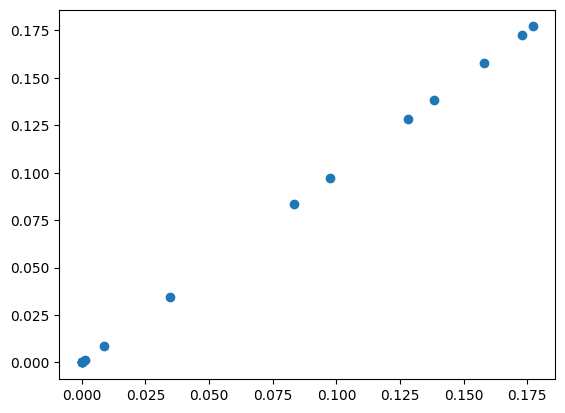

In [11]:
plt.scatter(obs_wpost, expected_wpost)

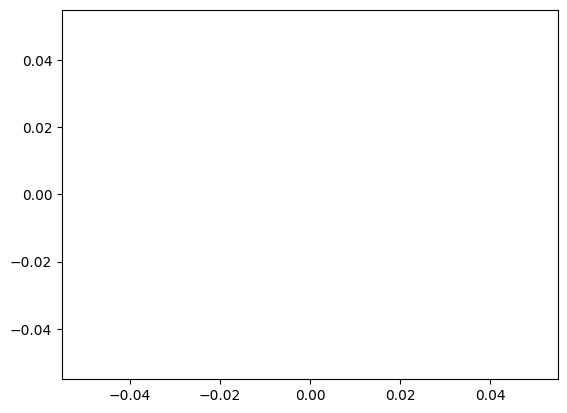

In [12]:
plt.scatter (post_mean, expected_post_mean)

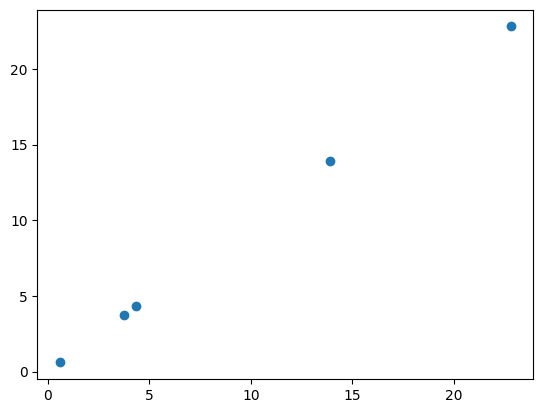

In [13]:
plt.scatter (post_mean2, expected_post_mean2)